In [1]:
import nilearn
from nilearn import datasets, plotting
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import MultiNiftiLabelsMasker
import os
import requests
import csv
import pandas as pd
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import scipy
from scipy.stats import multivariate_normal
from scipy.spatial.distance import pdist, squareform
from networkx.drawing.nx_agraph import graphviz_layout
from sklearn.metrics.cluster import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from scipy.sparse.csgraph import minimum_spanning_tree
from collections import deque, defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
import collections
from collections import defaultdict, deque
import copy

In [2]:
import torch
device = torch.device("gpu" if torch.cuda.is_available() else "cpu")

In [9]:
home_base_dir = '/Users/aj/dmello_lab/fmri_connectivity_trees' # directory where repository lives at home computer
lab_base_dir = '/Users/ajjain/Downloads/Code/fmri_connectivity_trees' # directory where repository lives at lab computer

# set base directory depending on where the code is being run
base_dir = home_base_dir if os.path.exists(home_base_dir) else lab_base_dir

# get schaefer
schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17, resolution_mm=1, data_dir=None, base_url=None, resume=True, verbose=1)
schaefer_coords = plotting.find_parcellation_cut_coords(labels_img=schaefer.maps)

subjects = [
            'MSC01', 
            'MSC03',
            'MSC04',
            'MSC05', 
            'MSC06',
            'MSC07', 
            'MSC08',
            ]

sessions = ['func01', 'func02', 'func03', 'func04', 'func05', 'func06', 'func07', 'func08', 'func09', 'func10']
ids = ['rest']
atlas = 'Schaefer'
atlas_subdir = "schaefer_100"

[get_dataset_dir] Dataset found in /Users/aj/nilearn_data/schaefer_2018

In [6]:
schaefer.labels

array([b'17Networks_LH_VisCent_ExStr_1', b'17Networks_LH_VisCent_ExStr_2',
       b'17Networks_LH_VisCent_Striate_1',
       b'17Networks_LH_VisCent_ExStr_3',
       b'17Networks_LH_VisPeri_ExStrInf_1',
       b'17Networks_LH_VisPeri_StriCal_1',
       b'17Networks_LH_VisPeri_ExStrSup_1', b'17Networks_LH_SomMotA_1',
       b'17Networks_LH_SomMotA_2', b'17Networks_LH_SomMotB_Aud_1',
       b'17Networks_LH_SomMotB_S2_1', b'17Networks_LH_SomMotB_S2_2',
       b'17Networks_LH_SomMotB_Cent_1',
       b'17Networks_LH_DorsAttnA_TempOcc_1',
       b'17Networks_LH_DorsAttnA_ParOcc_1',
       b'17Networks_LH_DorsAttnA_SPL_1',
       b'17Networks_LH_DorsAttnB_PostC_1',
       b'17Networks_LH_DorsAttnB_PostC_2',
       b'17Networks_LH_DorsAttnB_PostC_3',
       b'17Networks_LH_DorsAttnB_FEF_1',
       b'17Networks_LH_SalVentAttnA_ParOper_1',
       b'17Networks_LH_SalVentAttnA_Ins_1',
       b'17Networks_LH_SalVentAttnA_Ins_2',
       b'17Networks_LH_SalVentAttnA_ParMed_1',
       b'17Networks_LH_

In [ ]:
def load_data(subjects=subjects, measure="mutual_information", task="rest", atlas="Schaefer", atlas_subdir="schaefer_100", skl=False, num_bins=100):
    """
    Save the covariance matrix to a CSV file.
    """
    data = {}
    for subject in subjects:
        data_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/{measure}/{subject}/{atlas_subdir}'
        if skl:
            file_name = f'{task}_skl_{num_bins}bins'
        else:
            file_name = f'{task}_{num_bins}bins'

        data[subject] = torch.from_numpy(np.load(f'{data_path}/{file_name}.npy'))
    return data

def plot_connectome(cov_matrix, coords, title='connectome', edge_threshold="0%", edge_vmin=0, edge_vmax=1):
    """
    Plot the connectome using the mean correlation matrix and coordinates.
    """
    # Plotting the connectome
    plotting.plot_connectome(
        cov_matrix,
        coords,
        title=title,
        edge_vmin = edge_vmin,
        edge_vmax = edge_vmax,
        edge_cmap='cold_hot',
        edge_threshold=edge_threshold,  # Only plot edges above the 90th percentile
        colorbar=True,
        node_size=10,
    )
    plt.show()

def mi_to_graph(mi, selected_nodes=None):
    
    # Create a graph
    G = nx.Graph()
    num_variables = mi.shape[0]
    
    if selected_nodes is not None:
        for i in selected_nodes:
            G.add_node(i)
        
        for i in range(num_variables):
            for j in range(i + 1, num_variables):
                G.add_edge(selected_nodes[i], selected_nodes[j], weight=mi[i, j])

    else:
        # Add nodes (variables)
        for i in range(num_variables):
            G.add_node(i)

    # Add edges with mutual information as weights
        for i in range(num_variables):
            for j in range(i + 1, num_variables):
                G.add_edge(i, j, weight=mi[i, j])
    
    return G

def chow_liu_tree(mi):
    
    # Create a graph
    G = mi_to_graph(mi)

    # Find the maximum spanning tree
    # The weight parameter specifies the attribute used for edge weights
    chow_liu_tree = nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')
    
    return G, chow_liu_tree

def get_chow_liu_trees(mi, joint_probs, subjects=subjects):

    cl_trees = {}
    cl_matrices = {}
    cl_joint_probs = {}
    for subject in subjects:
        _, cl_trees[subject] = chow_liu_tree(mi[subject])
        cl_matrices[subject] = torch.from_numpy(nx.to_numpy_array(cl_trees[subject], weight='weight'))
        cl_joint_probs[subject] = {}
        for edge in cl_trees[subject].edges():
            i, j = edge
            cl_joint_probs[subject][edge] = joint_probs[subject][i, j, :, :]

    return cl_trees, cl_matrices, cl_joint_probs

def draw_chow_liu_tree(G, root=0):
    """
    Visualize the Chow-Liu tree using a spring layout (no pygraphviz).
    """
    tree = nx.bfs_tree(G, source=root)
    pos = nx.spring_layout(tree, seed=42)

    plt.figure(figsize=(8, 6))
    nx.draw(tree, pos, with_labels=True, arrows=False, node_color="lightblue", 
            edge_color="black", node_size=1500, font_size=12)
    
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in tree.edges()}
    nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels)

    plt.title("Chow-Liu Tree (Spring Layout)")
    plt.axis("off")
    plt.show()


def hierarchy_pos(G, root=None, width=1., vert_gap=0.5, vert_loc=0, xcenter=0.5):
    """
    Hierarchical layout for directed trees. Assigns space to subtrees to avoid squishing.
    """
    def _count_descendants(G, node):
        children = list(G.successors(node))
        if not children:
            return 1
        return sum(_count_descendants(G, child) for child in children)

    def _hierarchy_pos(G, node, left, right, vert_loc, pos):
        center = (left + right) / 2
        pos[node] = (center, vert_loc)
        children = list(G.successors(node))
        if children:
            total = sum(_count_descendants(G, child) for child in children)
            dx = (right - left) / total
            next_left = left
            for child in children:
                size = _count_descendants(G, child)
                next_right = next_left + dx * size
                pos = _hierarchy_pos(G, child, next_left, next_right, vert_loc - vert_gap, pos)
                next_left = next_right
        return pos

    return _hierarchy_pos(G, root, 0, width, vert_loc, {})

def get_node_regions(tree):

    networks = []
    for node in tree.nodes:
        network = str(schaefer.labels[node]).split('_')[2]
        networks.append(network)
    return networks

def draw_hierarchical_tree(G, root=0, num_networks=17, title = "Hierarchical Chow-Liu Tree"):
    """
    Draw Chow-Liu tree in a hierarchical top-down format.
    """
    # Ensure it's a directed tree rooted at `root`
    tree = nx.bfs_tree(G, source=root)

    pos = hierarchy_pos(tree, root)

    networks = get_node_regions(tree)

    # Create a color map based on the networks
    color_map = []
    network_names = ['Cont', 'Default', 'DorsAttn', 'Limbic', 'SalVentAttn', 'SomMot', 'Vis']
    colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink']
    
    if num_networks == 17:
        network_names = ['ContA',
                        'ContB',
                        'ContC',
                        'DefaultA',
                        'DefaultB',
                        'DefaultC',
                        'DorsAttnA',
                        'DorsAttnB',
                        'LimbicA',
                        'LimbicB',
                        'SalVentAttnA',
                        'SalVentAttnB',
                        'SomMotA',
                        'SomMotB',
                        'TempPar',
                        'VisCent',
                        'VisPeri']
        
        colors = colors = [
                        "#e6194b",  # red
                        "#3cb44b",  # green
                        "#ffe119",  # yellow
                        "#4363d8",  # blue
                        "#f58231",  # orange
                        "#911eb4",  # purple
                        "#46f0f0",  # cyan
                        "#f032e6",  # magenta
                        "#bcf60c",  # lime
                        "#fabebe",  # pink
                        "#008080",  # teal
                        "#e6beff",  # lavender
                        "#9a6324",  # brown
                        "#fffac8",  # beige
                        "#800000",  # maroon
                        "#aaffc3",  # mint
                        "#808000",  # olive
                    ]

    for node, network in zip(tree.nodes, networks):
        if network in network_names:
            color_map.append(colors[network_names.index(network)])
        else:
            color_map.append(0)
    
    # color_map = np.array(color_map)
    # color_map = color_map / max(color_map)
    
    plt.figure(figsize=(10, 6))
    nx.draw(tree, pos, with_labels=True, node_color=color_map, node_size=140,
            arrows=False, font_size=6, edge_color='gray')


    # edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in tree.edges()}
    # nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels, font_size = 0)

    patches = [mpatches.Patch(color=color, label=network_name) for color, network_name in zip(colors, network_names)]
    plt.legend(handles=patches)

    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()

    return tree, pos, network_names, colors

In [50]:
schaefer.labels

array([b'17Networks_LH_VisCent_ExStr_1', b'17Networks_LH_VisCent_ExStr_2',
       b'17Networks_LH_VisCent_Striate_1',
       b'17Networks_LH_VisCent_ExStr_3',
       b'17Networks_LH_VisPeri_ExStrInf_1',
       b'17Networks_LH_VisPeri_StriCal_1',
       b'17Networks_LH_VisPeri_ExStrSup_1', b'17Networks_LH_SomMotA_1',
       b'17Networks_LH_SomMotA_2', b'17Networks_LH_SomMotB_Aud_1',
       b'17Networks_LH_SomMotB_S2_1', b'17Networks_LH_SomMotB_S2_2',
       b'17Networks_LH_SomMotB_Cent_1',
       b'17Networks_LH_DorsAttnA_TempOcc_1',
       b'17Networks_LH_DorsAttnA_ParOcc_1',
       b'17Networks_LH_DorsAttnA_SPL_1',
       b'17Networks_LH_DorsAttnB_PostC_1',
       b'17Networks_LH_DorsAttnB_PostC_2',
       b'17Networks_LH_DorsAttnB_PostC_3',
       b'17Networks_LH_DorsAttnB_FEF_1',
       b'17Networks_LH_SalVentAttnA_ParOper_1',
       b'17Networks_LH_SalVentAttnA_Ins_1',
       b'17Networks_LH_SalVentAttnA_Ins_2',
       b'17Networks_LH_SalVentAttnA_ParMed_1',
       b'17Networks_LH_

In [156]:
def select_networks(schaefer, networks=['DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'VisCent', 'VisPeri']):
    
    selected_nodes = []
    for i, label in enumerate(schaefer.labels):
        network = str(label).split('_')[2]
        if network in networks:
            selected_nodes.append(i)
    return selected_nodes

def selective_chow_liu_tree(mi, selected_nodes):
    
    # Create a graph
    selected_mi = mi[np.ix_(selected_nodes, selected_nodes)]
    
    G = mi_to_graph(selected_mi, selected_nodes=selected_nodes)

    # Find the maximum spanning tree
    # The weight parameter specifies the attribute used for edge weights
    chow_liu_tree = nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')
    
    return G, chow_liu_tree

def get_selective_chow_liu_trees(mi, joint_probs, subjects=subjects, selected_networks=['DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'VisCent', 'VisPeri']):
    
    selected_nodes = select_networks(schaefer, networks=selected_networks)

    selective_cl_trees = {}
    selective_cl_joint_probs = {}
    
    for subject in subjects:
        _, selective_cl_trees[subject] = selective_chow_liu_tree(mi[subject], selected_nodes=selected_nodes)
        selective_cl_joint_probs[subject] = {}
        for edge in selective_cl_trees[subject].edges():
            i, j = edge
            selective_cl_joint_probs[subject][edge] = joint_probs[subject][i, j, :, :]

    return selective_cl_trees, selective_cl_joint_probs, selected_nodes

In [11]:
mi = load_data()
mi_joint_probs = load_data(measure="joint_probs")
product_of_marginals = load_data(measure="product_of_marginals")

In [12]:
max(mi_joint_probs['MSC05'][0][1].flatten())

tensor(0.0071)

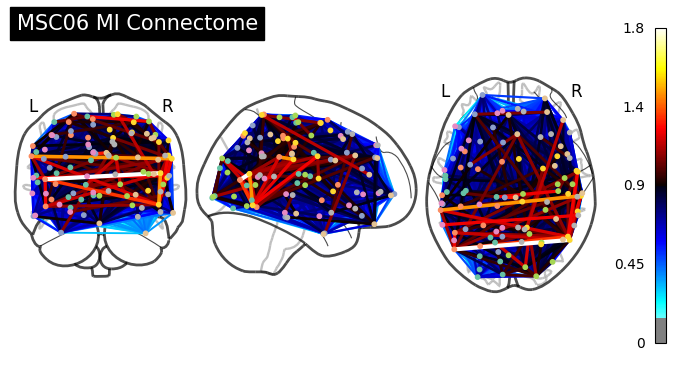

In [13]:
plot_connectome(mi['MSC06'], schaefer_coords, title='MSC06 MI Connectome', edge_threshold="0%", edge_vmax=max(mi['MSC06'].flatten()), edge_vmin=min(mi['MSC06'].flatten()))

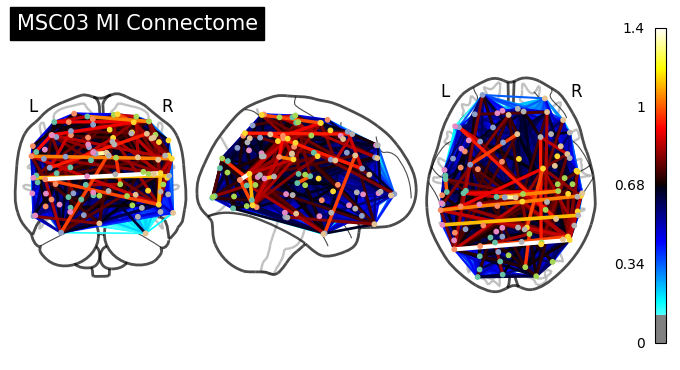

In [14]:
plot_connectome(mi['MSC03'], schaefer_coords, title='MSC03 MI Connectome', edge_threshold="0%", edge_vmax=max(mi['MSC03'].flatten()), edge_vmin=min(mi['MSC03'].flatten()))

In [157]:
cl_trees, cl_matrices, cl_joint_probs = get_chow_liu_trees(mi, mi_joint_probs, subjects=subjects)
selective_cl_trees, selective_cl_joint_probs, selected_nodes = get_selective_chow_liu_trees(mi, mi_joint_probs, subjects=subjects, selected_networks=['DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'VisCent', 'VisPeri'])

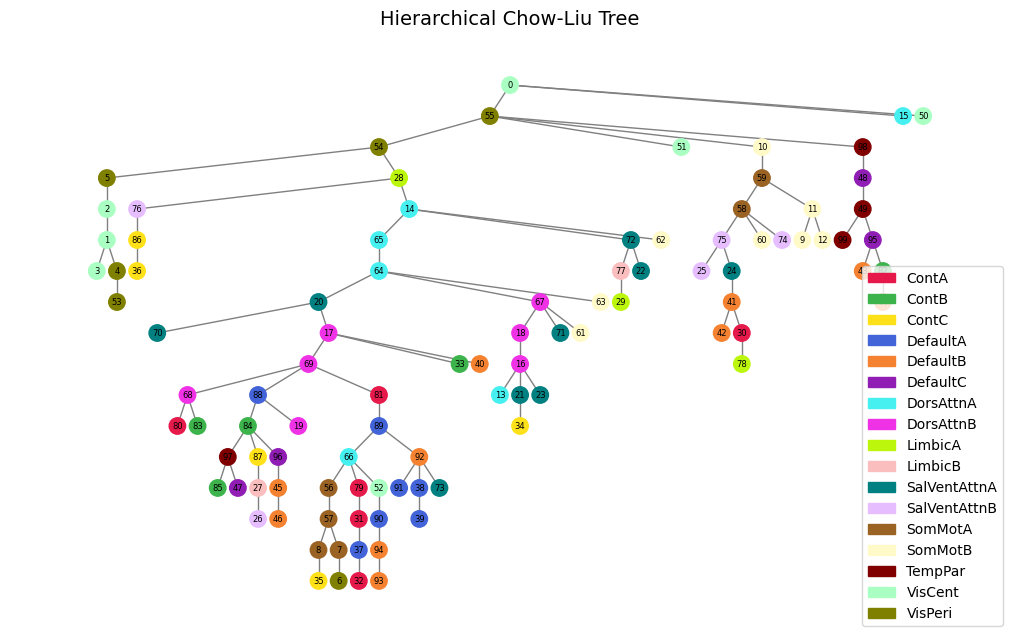

In [92]:
tree, pos, network_names, colors = draw_hierarchical_tree(cl_trees['MSC03'], root=0)

In [103]:
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees['MSC09'], root=0)

KeyError: 'MSC09'

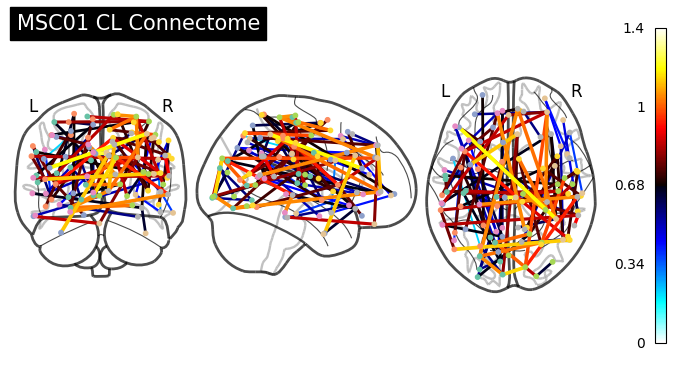

In [89]:
plot_connectome(nx.to_numpy_array(cl_trees['MSC01']), schaefer_coords, title='MSC01 CL Connectome', edge_threshold="0%", edge_vmax=max(mi['MSC03'].flatten()), edge_vmin=min(mi['MSC03'].flatten()))

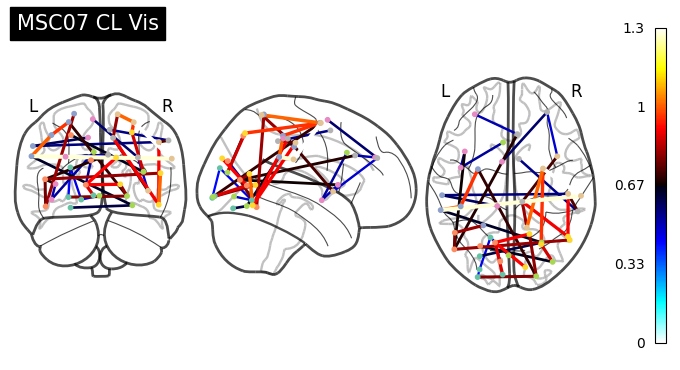

In [116]:
plot_connectome(nx.to_numpy_array(selective_cl_trees['MSC07']), schaefer_coords[selected_nodes], title='MSC07 CL Vis', edge_threshold="0%", edge_vmax=max(mi['MSC07'].flatten()), edge_vmin=min(mi['MSC03'].flatten()))

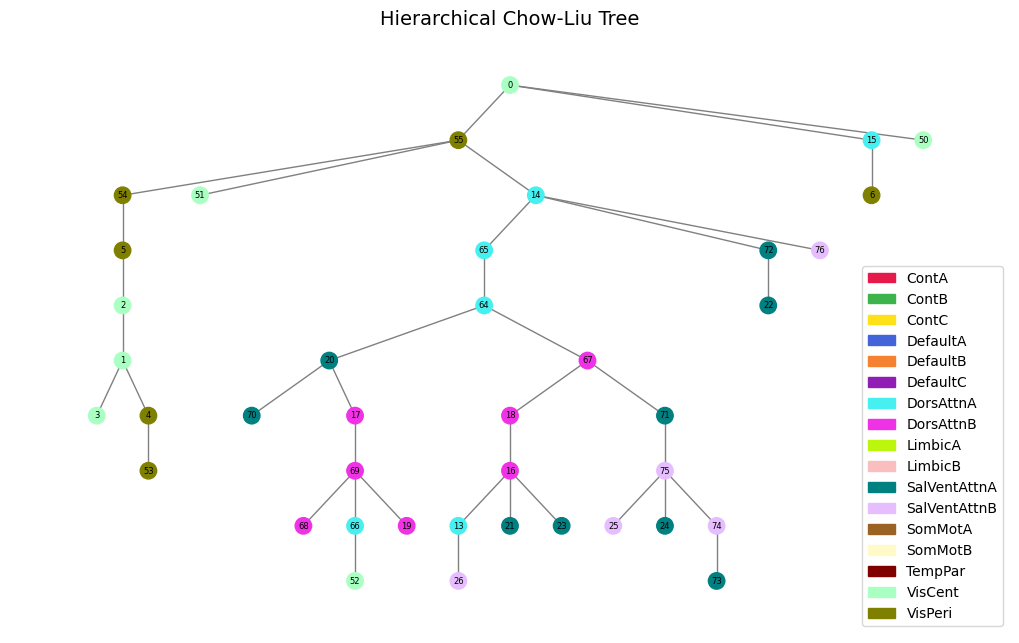

In [71]:
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees['MSC03'], root=0)

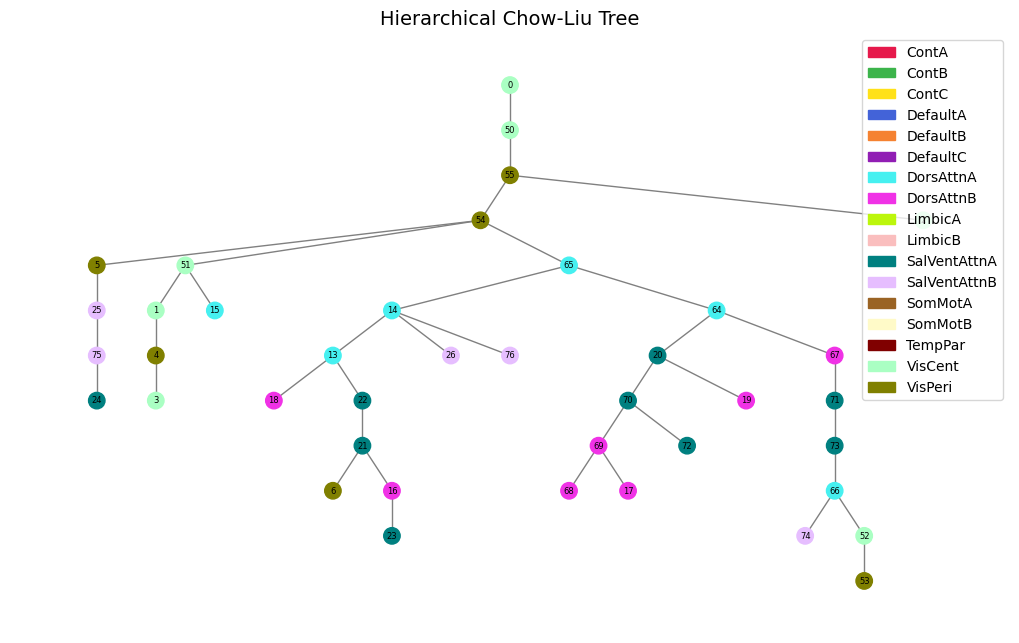

In [182]:
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees['MSC04'], root=0)

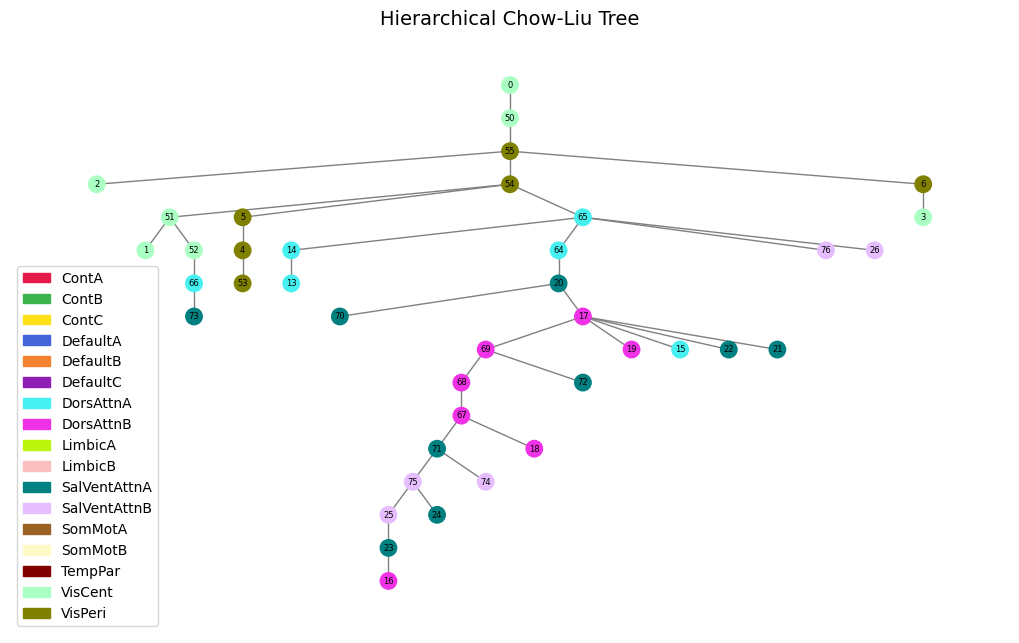

In [74]:
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees['MSC05'], root=0)

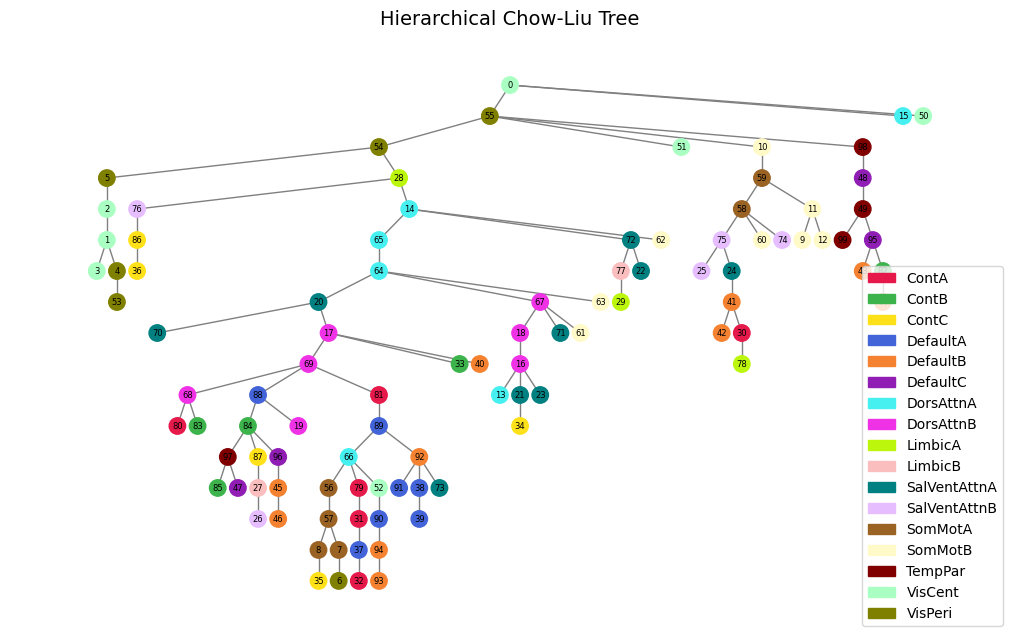

In [21]:
tree, pos, network_names, colors = draw_hierarchical_tree(cl_trees['MSC03'], root=0)

In [83]:
def derive_joint_probs_abc(a, b, c, joint_probs):
    """
    Get the joint probability of three variables a, b, and c.
    Given that a and b exists, b and c exists, but a and c does not exist
    """
    # p_ab = cl_joint_probs[subject][(a, b)]
    # p_bc = cl_joint_probs[subject][(b, c)]
    # p_b = np.sum(p_bc, axis=1)
    # p_cb_conditional = p_bc / (p_b[:, None] + 1e-10)  # Avoid division by zero
        # Add a check for the keys to prevent KeyError
        
    return joint_probs[(a, b)][:, :, None] * (joint_probs[(b, c)] / joint_probs[(b, c)].sum(axis=1)[:, None] + 1e-10)[None, :, :]

# marginalize by integrating over b
def marginalize_over_b(p_abc):
    """
    Marginalize the joint probability p_abc over b to get p_ac.
    p_abc is a 3D array with shape (num_bins_a, num_bins_b, num_bins_c)
    """
    return p_abc.sum(axis=1)

# derive mutual information from joint probability
def derive_mutual_info(p_ac):
    
    return torch.sum(p_ac * torch.log(p_ac / torch.outer(p_ac.sum(axis=1), p_ac.sum(axis=0)) + 1e-10))
                    


In [ ]:
def cl_tree_traversal(cl_joint_probs, cl_trees, cl_matrices, subject='MSC01', selected_nodes=None, selective_cl_trees=None, selective_cl_joint_probs=None):    

    """
    Traverse the Chow-Liu tree and reconstruct the mutual information matrix.  
    """
    
    if selected_nodes is None:
        joint_probs = copy.deepcopy(cl_joint_probs[subject])
        tree = cl_trees[subject].copy()
        cl_matrix = cl_matrices[subject].clone().to(device)
        mi_recon = cl_matrix.clone().to(device)
    
    ## TO DO ##
    elif selected_nodes is not None:
        if selective_cl_trees is None:
            raise ValueError("selective_cl_trees must be provided when selected_nodes is specified.")
        if selective_cl_joint_probs is None:
            raise ValueError("selective_cl_trees must be provided when selected_nodes is specified.")
        joint_probs = copy.deepcopy(selective_cl_joint_probs[subject])
        tree = selective_cl_trees[subject].copy()
        # cl_matrix = torch.from_numpy(nx.to_numpy_array(tree, weight='weight'))
       
    # mi_recon = cl_matrices[subject].clone().to(device) 
    visited = []
    
    # add first node in the tree to start traversal
    nodes = [list(tree.nodes)[0]]

    calc_bool = cl_matrices[subject].bool().to(device)
    
    if selected_nodes is not None:
        
        cl_matrix = torch.zeros_like(cl_matrices[subject]).to(device)
        mi_recon = torch.zeros_like(cl_matrices[subject]).to(device)
        
        for i, j in tree.edges():
            mi_recon[i, j] = tree[i][j]['weight']
            cl_matrix[i, j] = tree[i][j]['weight']
            
        calc_bool = calc_bool.fill_(True)
        for node in selected_nodes:
            for node_2 in selected_nodes[1:]:
                calc_bool[node, node_2] = False

    
    calc_bool.fill_diagonal_(True)  # Set diagonal to True since MI of a variable with itself is 0
        

    while False in calc_bool:

        # print(nodes)
        if len(nodes) == 0:
            break
        
        parent = nodes.pop()
        break_now = False
        
        while parent in visited:
           
            if parent in visited and len(nodes) == 0:
                break_now = True
                break
        
            parent = nodes.pop()
        
        if break_now:
            break
            
        visited.append(parent)
        print("# MI calculated: ", calc_bool.sum() / (calc_bool.shape[0] * calc_bool.shape[1]))
        print("parent: ", parent)
        children = list(tree.neighbors(parent))
        # nodes = nodes + children
        #print(children)
        
        for child in children:
            if child not in visited:
                nodes.append(child)

        while children: 

            child = children.pop()
            # print("child: ", child)
            
            # if child not in nodes and len(children) == 0:
            #     # nodes.append(child)

            # make sure edge goes both ways
            if (child, parent) not in tree.edges():
                tree.add_edge(child, parent)

            # print("child, parent: ", child, parent)

            if joint_probs.get((parent, child)) is None:
                joint_probs[(parent, child)] = joint_probs[(child, parent)].clone().to(device).T
            
            elif joint_probs.get((child, parent)) is None:
                joint_probs[(child, parent)] = joint_probs[(parent, child)].clone().to(device).T

            for sibling in children:
                # print("child, sibling: ", child, sibling)
                if calc_bool[child, sibling]:
                    continue
                
                if child not in nodes:
                    nodes.append(child)

                if joint_probs.get((parent, sibling)) is None:
                    joint_probs[(parent, sibling)] = joint_probs[(sibling, parent)].clone().to(device).T
            
                elif joint_probs.get((sibling, parent)) is None:
                    joint_probs[(sibling, parent)] = joint_probs[(parent, sibling)].clone().to(device).T

                # connect child to all its "siblings" through the mutual "parent"
                joint_prob_all = derive_joint_probs_abc(child, parent, sibling, joint_probs)
                joint_probs[(child, sibling)] = marginalize_over_b(joint_prob_all)
                joint_probs[(sibling, child)] = joint_probs[(child, sibling)].clone().to(device).T
                mi_recon[child, sibling] = derive_mutual_info(joint_probs[(child, sibling)])
                mi_recon[sibling, child] = mi_recon[child, sibling]

                # add to tree
                tree.add_edge(child, sibling)
                tree.add_edge(sibling, child)

                # mark MI as calculated
                calc_bool[child, sibling], calc_bool[sibling, child] = True, True

                # if child not in nodes:
                #     nodes.append(child)
            
            # nodes.append(child)
    
    if selected_nodes is not None:
        return mi_recon[np.ix_(selected_nodes, selected_nodes)], joint_probs
    
    return mi_recon, joint_probs

In [241]:
smi_recon, sjoint_probs = cl_tree_traversal(cl_joint_probs, selective_cl_trees, cl_matrices, 'MSC03', selective_cl_trees=selective_cl_trees, selective_cl_joint_probs=selective_cl_joint_probs, selected_nodes=selected_nodes)

# MI calculated:  tensor(0.8479)
parent:  0
# MI calculated:  tensor(0.8485)
parent:  50
# MI calculated:  tensor(0.8485)
parent:  15
# MI calculated:  tensor(0.8489)
parent:  55
# MI calculated:  tensor(0.8515)
parent:  6
# MI calculated:  tensor(0.8521)
parent:  54
# MI calculated:  tensor(0.8533)
parent:  51
# MI calculated:  tensor(0.8535)
parent:  5
# MI calculated:  tensor(0.8549)
parent:  14
# MI calculated:  tensor(0.8605)
parent:  2
# MI calculated:  tensor(0.8633)
parent:  76
# MI calculated:  tensor(0.8635)
parent:  1
# MI calculated:  tensor(0.8685)
parent:  65
# MI calculated:  tensor(0.8717)
parent:  4
# MI calculated:  tensor(0.8749)
parent:  64
# MI calculated:  tensor(0.8817)
parent:  53
# MI calculated:  tensor(0.8821)
parent:  67
# MI calculated:  tensor(0.8895)
parent:  20
# MI calculated:  tensor(0.8981)
parent:  71
# MI calculated:  tensor(0.9029)
parent:  70
# MI calculated:  tensor(0.9031)
parent:  75
# MI calculated:  tensor(0.9175)
parent:  3
# MI calculated: 

In [242]:
mi_recon, joint_probs = cl_tree_traversal(cl_joint_probs, cl_trees, cl_matrices, 'MSC03')

# MI calculated:  tensor(0.0298)
parent:  0
# MI calculated:  tensor(0.0304)
parent:  50
# MI calculated:  tensor(0.0304)
parent:  15
# MI calculated:  tensor(0.0304)
parent:  55
# MI calculated:  tensor(0.0340)
parent:  98
# MI calculated:  tensor(0.0354)
parent:  54
# MI calculated:  tensor(0.0388)
parent:  48
# MI calculated:  tensor(0.0408)
parent:  28
# MI calculated:  tensor(0.0454)
parent:  49
# MI calculated:  tensor(0.0508)
parent:  76
# MI calculated:  tensor(0.0538)
parent:  95
# MI calculated:  tensor(0.0604)
parent:  86
# MI calculated:  tensor(0.0640)
parent:  82
# MI calculated:  tensor(0.0678)
parent:  36
# MI calculated:  tensor(0.0678)
parent:  44
# MI calculated:  tensor(0.0678)
parent:  99
# MI calculated:  tensor(0.0678)
parent:  43
# MI calculated:  tensor(0.0678)
parent:  14
# MI calculated:  tensor(0.0804)
parent:  51
# MI calculated:  tensor(0.0804)
parent:  62
# MI calculated:  tensor(0.0804)
parent:  72
# MI calculated:  tensor(0.0898)
parent:  65
# MI calcul

In [47]:
cl_trees['MSC01'].edges()

EdgeView([(0, 2), (0, 91), (0, 50), (0, 24), (1, 54), (1, 4), (2, 55), (2, 76), (2, 15), (3, 4), (3, 53), (5, 54), (5, 55), (6, 39), (6, 7), (7, 57), (8, 57), (9, 11), (9, 10), (10, 59), (10, 23), (12, 61), (13, 22), (14, 65), (14, 20), (15, 32), (16, 22), (16, 21), (17, 69), (18, 33), (18, 22), (19, 35), (20, 70), (21, 34), (21, 42), (22, 72), (22, 75), (22, 27), (25, 75), (26, 34), (28, 76), (29, 77), (30, 43), (31, 79), (31, 37), (34, 46), (35, 49), (36, 86), (38, 39), (40, 99), (41, 93), (43, 95), (43, 91), (43, 44), (45, 96), (45, 47), (46, 47), (48, 98), (49, 99), (51, 55), (51, 52), (54, 57), (55, 75), (55, 98), (56, 66), (58, 59), (58, 75), (58, 73), (58, 60), (60, 74), (61, 62), (62, 63), (63, 72), (63, 64), (65, 72), (66, 73), (67, 72), (68, 71), (69, 70), (71, 72), (71, 83), (74, 80), (75, 77), (76, 86), (78, 93), (79, 91), (79, 93), (79, 90), (81, 97), (82, 94), (83, 87), (83, 84), (84, 85), (85, 97), (86, 99), (87, 94), (88, 99), (89, 92), (91, 92)])

In [23]:
cl_joint_probs['MSC01'][(0, 24)]

tensor([[1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10],
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10],
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10],
        ...,
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10],
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10],
        [1.0000e-10, 1.0000e-10, 1.0000e-10,  ..., 1.0000e-10, 1.0000e-10,
         1.0000e-10]])

In [48]:
sum(mi_recon.flatten() > 0)

tensor(9900)

In [236]:
sum(mi['MSC01'].flatten() > 0)

tensor(9900)

In [221]:
nx.is_connected(cl_trees['MSC01'])

True

In [265]:
mi_recon[0][:]

tensor([0.0000, 0.1366, 0.2202, 0.0976, 0.0929, 0.3097, 0.0166, 0.0243, 0.0267,
        0.1368, 0.3420, 0.1643, 0.0974, 0.0428, 0.2151, 0.6993, 0.0619, 0.1094,
        0.0891, 0.0458, 0.1318, 0.0407, 0.1068, 0.0398, 0.0792, 0.0954, 0.0080,
        0.0185, 0.2926, 0.0875, 0.0089, 0.0310, 0.0067, 0.0834, 0.0202, 0.0197,
        0.1129, 0.0246, 0.0264, 0.0136, 0.0722, 0.0417, 0.0238, 0.0293, 0.0141,
        0.0129, 0.0039, 0.0109, 0.1745, 0.0982, 0.6858, 0.3679, 0.0258, 0.0588,
        0.4639, 0.7009, 0.0380, 0.0304, 0.1753, 0.2330, 0.1224, 0.0712, 0.1343,
        0.1277, 0.1686, 0.1957, 0.0482, 0.1284, 0.0762, 0.0897, 0.1147, 0.0825,
        0.1654, 0.0256, 0.1107, 0.1316, 0.2330, 0.1174, 0.0051, 0.0366, 0.0571,
        0.0703, 0.0254, 0.0508, 0.0488, 0.0163, 0.1247, 0.0297, 0.0703, 0.0573,
        0.0170, 0.0257, 0.0403, 0.0069, 0.0101, 0.0523, 0.0263, 0.0311, 0.3203,
        0.0853], dtype=torch.float64)

In [266]:
mi['MSC03'][0][:]

tensor([0.0000, 0.3919, 0.4201, 0.3197, 0.3377, 0.4538, 0.5086, 0.4675, 0.3873,
        0.3798, 0.4941, 0.3697, 0.4169, 0.4872, 0.5492, 0.6993, 0.4340, 0.4881,
        0.4949, 0.2653, 0.4078, 0.3637, 0.5536, 0.3623, 0.3331, 0.3742, 0.2150,
        0.3381, 0.6553, 0.3800, 0.1891, 0.3937, 0.2443, 0.4337, 0.2174, 0.3211,
        0.2941, 0.5064, 0.3787, 0.2651, 0.4218, 0.3640, 0.3347, 0.2064, 0.3565,
        0.2014, 0.1486, 0.1967, 0.3640, 0.3729, 0.6858, 0.5196, 0.2864, 0.3173,
        0.6444, 0.7009, 0.4312, 0.4217, 0.3682, 0.3930, 0.3163, 0.3421, 0.4172,
        0.4163, 0.4943, 0.5565, 0.3718, 0.4440, 0.3837, 0.3838, 0.4258, 0.3437,
        0.4746, 0.3648, 0.2679, 0.3749, 0.4595, 0.4284, 0.1584, 0.3795, 0.2686,
        0.2944, 0.3801, 0.3700, 0.4286, 0.2554, 0.3119, 0.3833, 0.4311, 0.3630,
        0.2782, 0.3964, 0.4490, 0.3173, 0.3047, 0.4110, 0.3342, 0.3397, 0.5137,
        0.3841])

Text(0.5, 1.0, 'MSC03 Resting-State Original MI vs. Derived MI from CL Tree')

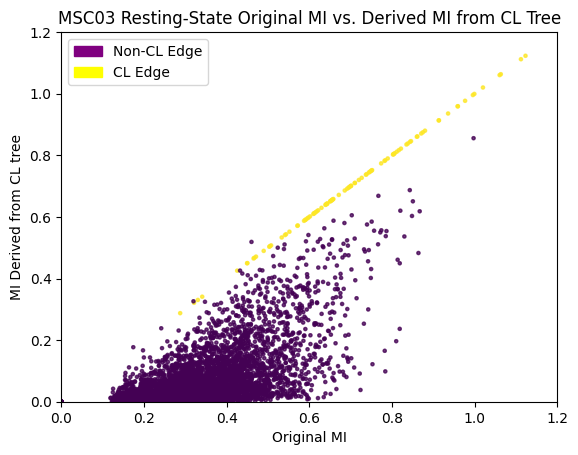

In [203]:
plt.scatter(mi['MSC03'].flatten(), mi_recon.flatten(), c=cl_matrices['MSC03'].bool(), alpha=0.5, s=5)
plt.legend(handles=[mpatches.Patch(color='purple', label='Non-CL Edge'), mpatches.Patch(color='yellow', label='CL Edge')])
plt.xlim(0, 1.2)
plt.ylim(0, 1.2)
plt.xlabel("Original MI")
plt.ylabel("MI Derived from CL tree")
plt.title("MSC03 Resting-State Original MI vs. Derived MI from CL Tree")

In [220]:
len(mi['MSC01'][np.ix_(selected_nodes, selected_nodes)].flatten())

1600

In [254]:
mi['MSC03'][np.ix_(selected_nodes, selected_nodes)]

tensor([[0.0000, 0.3919, 0.4201,  ..., 0.2679, 0.3749, 0.4595],
        [0.3919, 0.0000, 0.6435,  ..., 0.2513, 0.3510, 0.4014],
        [0.4201, 0.6435, 0.0000,  ..., 0.3200, 0.4309, 0.4484],
        ...,
        [0.2679, 0.2513, 0.3200,  ..., 0.0000, 0.5966, 0.4417],
        [0.3749, 0.3510, 0.4309,  ..., 0.5966, 0.0000, 0.4735],
        [0.4595, 0.4014, 0.4484,  ..., 0.4417, 0.4735, 0.0000]])

In [263]:
torch.from_numpy(nx.to_numpy_array(selective_cl_trees['MSC03']))[0][:]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.6993, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.6858, 0.0000, 0.0000, 0.0000, 0.0000, 0.7009,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000], dtype=torch.float64)

In [261]:
smi_recon[0][:]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.6993, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.6858, 0.0000, 0.0000, 0.0000, 0.0000, 0.7009,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000], dtype=torch.float64)

In [255]:
smi_recon

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0251,  ..., 0.0209, 0.0337, 0.0987],
        [0.0000, 0.0251, 0.0000,  ..., 0.0315, 0.0511, 0.1550],
        ...,
        [0.0000, 0.0209, 0.0315,  ..., 0.0000, 0.0007, 0.0679],
        [0.0000, 0.0337, 0.0511,  ..., 0.0007, 0.0000, 0.1128],
        [0.0000, 0.0987, 0.1550,  ..., 0.0679, 0.1128, 0.0000]],
       dtype=torch.float64)

In [245]:
len(smi_recon.flatten())

1600

Text(0.5, 1.0, 'MSC03 Resting-State Original MI vs. Derived MI from CL Tree')

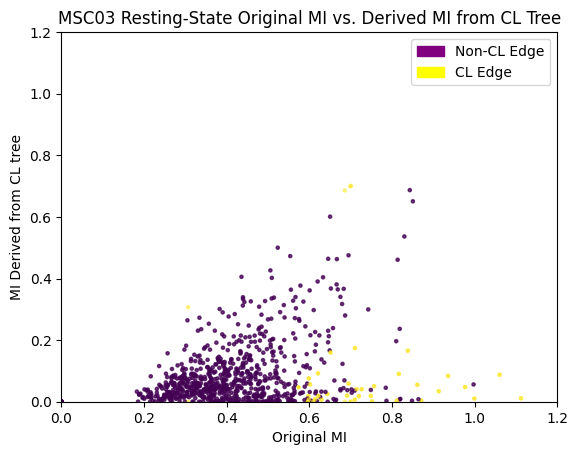

In [243]:
plt.scatter(mi['MSC03'][np.ix_(selected_nodes, selected_nodes)].flatten(), smi_recon.flatten(), c=torch.from_numpy(nx.to_numpy_array(selective_cl_trees['MSC03'])).bool(), alpha=0.5, s=5)
plt.legend(handles=[mpatches.Patch(color='purple', label='Non-CL Edge'), mpatches.Patch(color='yellow', label='CL Edge')])
plt.xlim(0, 1.2)
plt.ylim(0, 1.2)
plt.xlabel("Original MI")
plt.ylabel("MI Derived from CL tree")
plt.title("MSC03 Resting-State Original MI vs. Derived MI from CL Tree")

Text(0.5, 1.0, 'MSC03 Resting-State Original MI vs. Derived MI from CL Tree')

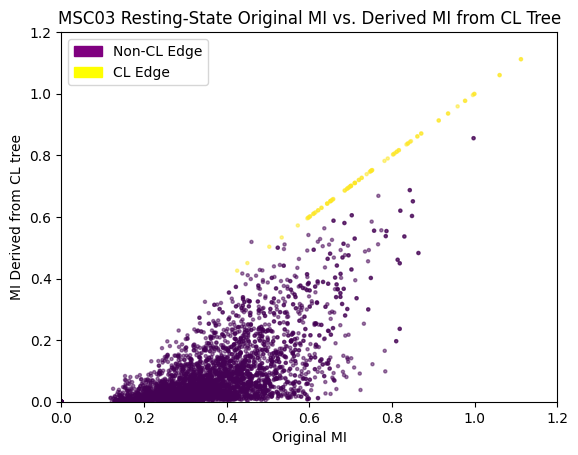

In [87]:
plt.scatter(mi['MSC03'][selected_nodes].flatten(), mi_recon[selected_nodes].flatten(), c=cl_matrices['MSC03'][selected_nodes].bool(), alpha=0.5, s=5)
plt.legend(handles=[mpatches.Patch(color='purple', label='Non-CL Edge'), mpatches.Patch(color='yellow', label='CL Edge')])
plt.xlim(0, 1.2)
plt.ylim(0, 1.2)
plt.xlabel("Original MI")
plt.ylabel("MI Derived from CL tree")
plt.title("MSC03 Resting-State Original MI vs. Derived MI from CL Tree")

In [120]:
smi_recon, sjoint_probs = cl_tree_traversal(cl_joint_probs, cl_trees, cl_matrices, 'MSC03', selective_cl_trees=selective_cl_trees, selected_nodes=selected_nodes)

TypeError: unhashable type: 'list'

# MI calculated:  tensor(0.0298)
parent:  0
[15, 50]
# MI calculated:  tensor(0.0300)
parent:  50
[0, 15]
# MI calculated:  tensor(0.0300)
parent:  15
[0, 51, 37, 50]
# MI calculated:  tensor(0.0310)
parent:  50
[0, 15, 51, 37]
# MI calculated:  tensor(0.0310)
parent:  37
[15, 50, 0, 51]
# MI calculated:  tensor(0.0310)
parent:  51
[15, 55, 50, 37, 0]
# MI calculated:  tensor(0.0318)
parent:  50
[0, 15, 51, 37, 55]
# MI calculated:  tensor(0.0318)
parent:  55
[2, 5, 51, 98, 0, 37, 50, 15]
# MI calculated:  tensor(0.0354)
parent:  50
[0, 15, 51, 37, 55, 2, 5, 98]
# MI calculated:  tensor(0.0354)
parent:  98
[48, 55, 15, 50, 37, 0, 2, 5, 51]
# MI calculated:  tensor(0.0370)
parent:  50
[0, 15, 51, 37, 55, 2, 5, 98, 48]
# MI calculated:  tensor(0.0370)
parent:  48
[98, 49, 51, 5, 2, 0, 37, 50, 15, 55]
# MI calculated:  tensor(0.0388)
parent:  50
[0, 15, 51, 37, 55, 2, 5, 98, 48, 49]
# MI calculated:  tensor(0.0388)
parent:  49
[48, 99, 55, 15, 50, 37, 0, 2, 5, 51, 98]
# MI calculated:  te

Text(0.5, 1.0, 'MSC08 Resting-State Original MI vs. Derived MI from CL Tree')

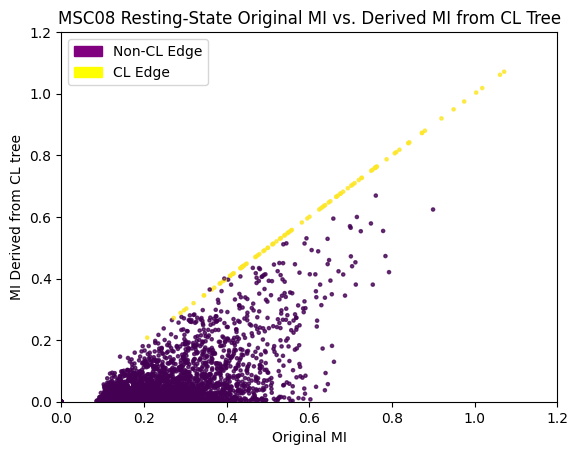

In [67]:
mi_recon_03, joint_probs_03 = cl_tree_traversal(cl_joint_probs, cl_trees, cl_matrices, subject='MSC08')
plt.scatter(mi['MSC08'].flatten(), mi_recon_03.flatten(), c=cl_matrices['MSC08'].bool(), alpha=0.5, s=5)
plt.legend(handles=[mpatches.Patch(color='purple', label='Non-CL Edge'), mpatches.Patch(color='yellow', label='CL Edge')])
plt.xlim(0, 1.2)
plt.ylim(0, 1.2)
plt.xlabel("Original MI")
plt.ylabel("MI Derived from CL tree")
plt.title("MSC08 Resting-State Original MI vs. Derived MI from CL Tree")